# Probabilistic Fantasy Point Scoring

The current pipeline predicts raw positions (clustered around 10-12), ranks them to 1-20 integers,
then looks up fantasy points from a scoring table. This introduces false precision for midfield
drivers and loses uncertainty information.

**Fix:** treat the raw prediction as the center of a probability distribution over finishing
positions. Compute expected fantasy points by integrating over all possible outcomes:

```
E[points] = sum over P=1..20 of Prob(finish=P) * scoring_rules(P) + Prob(DNF) * DNF_penalty
```

This should:
- Stop overestimating backmarkers (DNF risk pulls their expected value down)
- Stop underestimating frontrunners (upside from P1/P2 is properly weighted)
- Not over-differentiate between clustered midfield predictions

## Setup

In [1]:
import sys
sys.path.append('..')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm
import fastf1

from app.config import (
    PROCESSED_HISTORIC_FEATURES_DIR, PROCESSED_PRACTICE_FEATURES_DIR,
    PROCESSED_CIRCUIT_FEATURES_DIR, INTERIM_EVENTS_DIR, INTERIM_RACES_DIR,
    INTERIM_QUALI_DIR, FANTASY_POINTS_DIR,
    TRAIN_SEASONS, VAL_SEASONS, TEST_SEASONS,
)
from app.models.configs import QUALI_POSITION_MODEL, FINISH_POSITION_MODEL
from app.models.predict import load_season_model
from app.models.compose import compose_drivers, compose_constructor
from app.data.overtakes import build_overtake_predictor
from app.data.dotd import build_dotd_predictor
from app.data.targets import load_fantasy_targets
from app.data.scoring_rules import (
    DRIVER_RACE_POSITION_POINTS, DRIVER_QUALI_POSITION_POINTS,
    FASTEST_LAP_POINTS, DOTD_POINTS, POSITION_GAINED_POINTS,
    RACE_PENALTY, OVERTAKE_MADE_POINTS,
)

predict_overtakes = build_overtake_predictor()
predict_dotd = build_dotd_predictor()

## Collect raw predictions and actuals

Run the prediction pipeline but keep the raw XGBoost outputs (before ranking) alongside
the ranked predictions, actual positions, and actual fantasy points.

In [2]:
from app.config import INTERIM_SPRINT_QUALIFYING_DIR

def predict_with_raw(quali_model, quali_config, finish_model, finish_config, season, round_num):
    """same as predict() but also returns the raw (pre-ranking) XGBoost outputs."""
    historic_features = pd.read_parquet(PROCESSED_HISTORIC_FEATURES_DIR / f"{season}_{round_num:02d}.parquet")

    practice_path = PROCESSED_PRACTICE_FEATURES_DIR / f"{season}_{round_num:02d}.parquet"
    practice_features = pd.read_parquet(practice_path) if practice_path.exists() else None

    if practice_features is not None:
        features = historic_features.merge(practice_features, on=["race_id", "driver_id"], how="left")
    else:
        features = historic_features.copy()
        practice_cols = set(c for c in quali_config["features"] + finish_config["features"] if c.startswith("fp"))
        for col in practice_cols:
            features[col] = float("nan")

    circuit_path = PROCESSED_CIRCUIT_FEATURES_DIR / f"{season}_{round_num:02d}.parquet"
    if circuit_path.exists():
        circuit_features = pd.read_parquet(circuit_path)
        features = features.merge(circuit_features, on="race_id", how="left")
    else:
        circuit_cols = set(c for c in quali_config["features"] + finish_config["features"] if c.startswith("circuit_"))
        for col in circuit_cols:
            features[col] = float("nan")

    sq_path = INTERIM_SPRINT_QUALIFYING_DIR / f"{season}_{round_num:02d}.parquet"
    if sq_path.exists():
        sq = pd.read_parquet(sq_path).set_index("driver_id")["sprint_quali_position"]
        features["sprint_quali_position"] = features["driver_id"].map(sq)
    else:
        features["sprint_quali_position"] = float("nan")

    for col in set(quali_config["features"] + finish_config["features"]):
        if col not in features.columns:
            features[col] = float("nan")

    # quali
    X_quali = features[quali_config["features"]]
    raw_quali = quali_model.predict(X_quali)
    features["predicted_quali_position"] = pd.Series(raw_quali).rank(method="first").astype(int).values

    # finish
    X_finish = features[finish_config["features"]]
    raw_finish = finish_model.predict(X_finish)
    features["predicted_finish_position"] = pd.Series(raw_finish).rank(method="first").astype(int).values

    return pd.DataFrame({
        "driver_id": features["driver_id"],
        "constructor_id": features["constructor_id"],
        "predicted_quali_position": features["predicted_quali_position"],
        "predicted_finish_position": features["predicted_finish_position"],
        "raw_quali": raw_quali,
        "raw_finish": raw_finish,
        "sprint_quali_position": features["sprint_quali_position"],
        "rolling_crash_dnf_rate_last_5": features["rolling_crash_dnf_rate_last_5"] if "rolling_crash_dnf_rate_last_5" in features.columns else 0.0,
    }).sort_values("predicted_finish_position").reset_index(drop=True)

In [3]:
rows = []

for season in [2023, 2024, 2025, 2026]:
    quali_model = load_season_model(QUALI_POSITION_MODEL, season)
    finish_model = load_season_model(FINISH_POSITION_MODEL, season)
    schedule = fastf1.get_event_schedule(season)
    schedule = schedule[schedule["RoundNumber"] > 0]

    for _, event in schedule.iterrows():
        rnd = event["RoundNumber"]
        fp = PROCESSED_HISTORIC_FEATURES_DIR / f"{season}_{rnd:02d}.parquet"
        tp = FANTASY_POINTS_DIR / f"{season}_{rnd:02d}.csv"
        if not (fp.exists() and tp.exists()):
            continue

        ep = INTERIM_EVENTS_DIR / f"{season}_{rnd:02d}.parquet"
        location = pd.read_parquet(ep)["location"].iloc[0] if ep.exists() else None

        preds = predict_with_raw(quali_model, QUALI_POSITION_MODEL, finish_model, FINISH_POSITION_MODEL, season, rnd)

        # actuals
        targets = load_fantasy_targets(season, rnd)
        driver_targets = targets[targets["asset_type"] == "driver"].set_index("asset_id")

        races_path = INTERIM_RACES_DIR / f"{season}_{rnd:02d}.parquet"
        quali_path = INTERIM_QUALI_DIR / f"{season}_{rnd:02d}.parquet"
        if not (races_path.exists() and quali_path.exists()):
            continue
        race_results = pd.read_parquet(races_path).set_index("driver_id")
        quali_results = pd.read_parquet(quali_path).set_index("driver_id")

        for _, row in preds.iterrows():
            did = row["driver_id"]
            if did not in driver_targets.index or did not in race_results.index:
                continue
            actual_finish = race_results.loc[did, "finish_position"]
            actual_quali = quali_results.loc[did, "quali_position"] if did in quali_results.index else np.nan
            if pd.isna(actual_finish) or pd.isna(actual_quali):
                continue

            rows.append({
                "season": season, "round": rnd, "driver_id": did,
                "constructor_id": row["constructor_id"],
                "raw_finish": row["raw_finish"],
                "raw_quali": row["raw_quali"],
                "ranked_finish": row["predicted_finish_position"],
                "ranked_quali": row["predicted_quali_position"],
                "actual_finish": int(actual_finish),
                "actual_quali": int(actual_quali),
                "actual_fantasy_pts": driver_targets.loc[did, "actual_fantasy_points"],
                "dnf_rate": row["rolling_crash_dnf_rate_last_5"],
                "sprint_quali_position": row["sprint_quali_position"],
                "location": location,
            })

    print(f"  {season}: done")

data = pd.DataFrame(rows)
print(f"\ntotal: {len(data)} driver-race records")
print(f"seasons: {sorted(data['season'].unique())}")
data.head()

req         WARNING 	DEFAULT CACHE ENABLED! (3.05 GB) C:\Users\gputs\AppData\Local\Temp\fastf1


  2023: done
  2024: done
  2025: done
  2026: done

total: 1503 driver-race records
seasons: [np.int64(2023), np.int64(2024), np.int64(2025), np.int64(2026)]


,season,round,driver_id,constructor_id,raw_finish,raw_quali,ranked_finish,ranked_quali,actual_finish,actual_quali,actual_fantasy_pts,dnf_rate,sprint_quali_position,location
0,2023,1,max_verstappen,red_bull,3.335258,2.258026,1,1,1,1,35,0.0,NaN,Sakhir
1,2023,1,sergio_perez,red_bull,4.654287,2.903755,2,2,2,2,28,0.0,NaN,Sakhir
2,2023,1,lewis_hamilton,mercedes,5.295223,5.519452,3,5,5,7,19,0.0,NaN,Sakhir
3,2023,1,carlos_sainz,ferrari,6.195699,5.330345,4,4,4,4,19,0.4,NaN,Sakhir
4,2023,1,george_russell,mercedes,7.317991,6.023478,5,6,7,6,16,0.0,NaN,Sakhir


## Understand the raw predictions

Before building the probabilistic scorer, look at the raw XGBoost outputs: how compressed
are they, and how do they relate to actual positions?

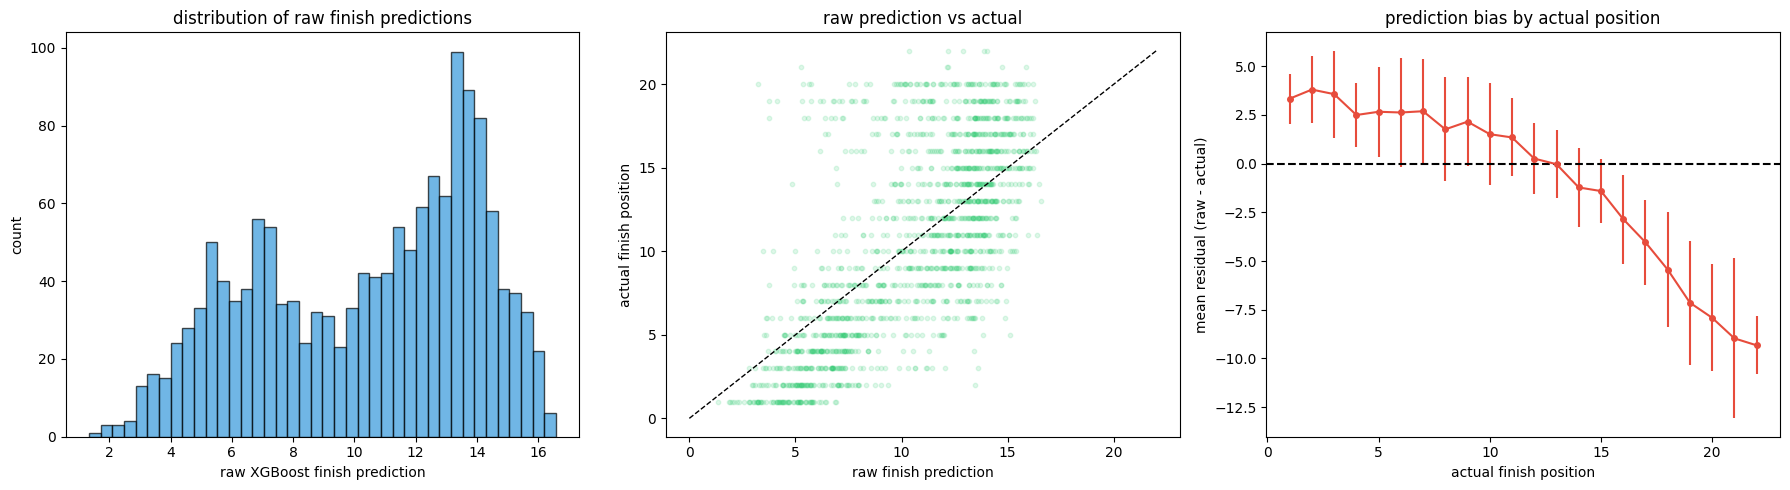

raw finish range: [1.3, 16.6]
raw finish std:   3.6
actual finish std: 5.8

per-race raw prediction spread:
  mean range: 11.8
  mean std:   3.7


In [4]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# raw prediction distribution
axes[0].hist(data["raw_finish"], bins=40, color="#3498db", alpha=0.7, edgecolor="black")
axes[0].set_xlabel("raw XGBoost finish prediction")
axes[0].set_ylabel("count")
axes[0].set_title("distribution of raw finish predictions")

# raw vs actual
axes[1].scatter(data["raw_finish"], data["actual_finish"], alpha=0.15, s=10, color="#2ecc71")
axes[1].plot([0, 22], [0, 22], "k--", lw=1)
axes[1].set_xlabel("raw finish prediction")
axes[1].set_ylabel("actual finish position")
axes[1].set_title("raw prediction vs actual")

# residual (raw - actual) by actual position
data["raw_residual"] = data["raw_finish"] - data["actual_finish"]
residual_by_pos = data.groupby("actual_finish")["raw_residual"].agg(["mean", "std"]).reset_index()
axes[2].errorbar(residual_by_pos["actual_finish"], residual_by_pos["mean"],
                 yerr=residual_by_pos["std"], fmt="o-", color="#e74c3c", markersize=4)
axes[2].axhline(0, color="black", ls="--")
axes[2].set_xlabel("actual finish position")
axes[2].set_ylabel("mean residual (raw - actual)")
axes[2].set_title("prediction bias by actual position")

plt.tight_layout()
plt.show()

# summary stats
print(f"raw finish range: [{data['raw_finish'].min():.1f}, {data['raw_finish'].max():.1f}]")
print(f"raw finish std:   {data['raw_finish'].std():.1f}")
print(f"actual finish std: {data['actual_finish'].std():.1f}")

# per-race compression: what's the spread of raw predictions within a single race?
race_spread = data.groupby(["season", "round"])["raw_finish"].agg(["min", "max", "std"])
print(f"\nper-race raw prediction spread:")
print(f"  mean range: {(race_spread['max'] - race_spread['min']).mean():.1f}")
print(f"  mean std:   {race_spread['std'].mean():.1f}")

## Estimate prediction uncertainty

Fit the residual standard deviation as a function of raw prediction. Drivers predicted to finish
near the top have tighter uncertainty than midfield/backmarkers. This gives us a per-driver
sigma to build probability distributions from.

We also estimate per-driver confidence intervals (upper/lower bounds) for the dashboard.

residual stats by raw prediction bin:
 mean_raw  residual_std  residual_mean   n
     2.20          0.45           1.20  10
     3.54          1.13           1.72  17
     5.17          1.70           1.94  31
     6.67          2.92           1.23  52
     7.96          5.09          -0.35  45
     9.58          5.26          -1.91  37
    11.00          4.35           0.49  55
    12.53          3.49          -0.93  63
    13.88          3.02          -0.78 103
    15.32          2.57          -1.64  26

sigma(raw) = 1.33 + 0.189 * raw_prediction


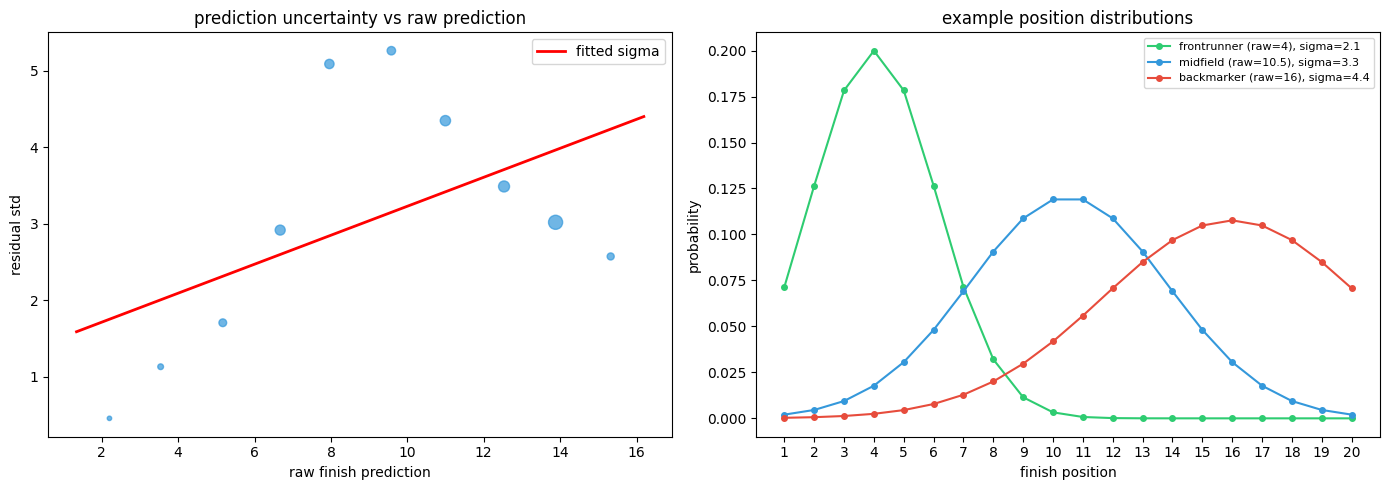


example 80% confidence intervals:
  verstappen-type: raw=3.5, sigma=2.0 -> P1-P6
  midfield: raw=10.5, sigma=3.3 -> P6-P15
  backmarker: raw=17.0, sigma=4.6 -> P11-P20


In [5]:
# use 2023 data to calibrate (held out from val/test), plus train seasons
cal_data = data[data["season"].isin(TRAIN_SEASONS + [2023])]

# bin raw predictions and compute residual stats per bin
cal_data = cal_data.copy()
cal_data["raw_bin"] = pd.cut(cal_data["raw_finish"], bins=10)
bin_stats = cal_data.groupby("raw_bin", observed=True).agg(
    mean_raw=("raw_finish", "mean"),
    residual_std=("raw_residual", "std"),
    residual_mean=("raw_residual", "mean"),
    n=("raw_residual", "count"),
).dropna().reset_index()

print("residual stats by raw prediction bin:")
print(bin_stats[["mean_raw", "residual_std", "residual_mean", "n"]].round(2).to_string(index=False))

# fit a simple linear model: sigma = a + b * raw_prediction
from numpy.polynomial import polynomial as P
coeffs = P.polyfit(bin_stats["mean_raw"], bin_stats["residual_std"], deg=1)
sigma_fn = lambda raw: max(coeffs[0] + coeffs[1] * raw, 1.5)  # floor at 1.5

print(f"\nsigma(raw) = {coeffs[0]:.2f} + {coeffs[1]:.3f} * raw_prediction")

# plot
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

raw_range = np.linspace(cal_data["raw_finish"].min(), cal_data["raw_finish"].max(), 100)
axes[0].scatter(bin_stats["mean_raw"], bin_stats["residual_std"], s=bin_stats["n"], color="#3498db", alpha=0.7)
axes[0].plot(raw_range, [sigma_fn(r) for r in raw_range], "r-", lw=2, label="fitted sigma")
axes[0].set_xlabel("raw finish prediction")
axes[0].set_ylabel("residual std")
axes[0].set_title("prediction uncertainty vs raw prediction")
axes[0].legend()

# show example distributions for a top driver, midfield, and backmarker
positions = np.arange(1, 21)
for raw_pred, label, color in [(4.0, "frontrunner (raw=4)", "#2ecc71"),
                                 (10.5, "midfield (raw=10.5)", "#3498db"),
                                 (16.0, "backmarker (raw=16)", "#e74c3c")]:
    sigma = sigma_fn(raw_pred)
    probs = norm.pdf(positions, loc=raw_pred, scale=sigma)
    probs = probs / probs.sum()  # normalize to valid PMF
    axes[1].plot(positions, probs, "o-", label=f"{label}, sigma={sigma:.1f}", color=color, markersize=4)

axes[1].set_xlabel("finish position")
axes[1].set_ylabel("probability")
axes[1].set_title("example position distributions")
axes[1].legend(fontsize=8)
axes[1].set_xticks(positions)

plt.tight_layout()
plt.show()

# confidence intervals: 80% CI for the dashboard
print("\nexample 80% confidence intervals:")
for raw_pred, driver in [(3.5, "verstappen-type"), (10.5, "midfield"), (17.0, "backmarker")]:
    sigma = sigma_fn(raw_pred)
    lo = raw_pred - 1.28 * sigma  # 10th percentile
    hi = raw_pred + 1.28 * sigma  # 90th percentile
    print(f"  {driver}: raw={raw_pred:.1f}, sigma={sigma:.1f} -> P{max(1,int(round(lo)))}-P{min(20,int(round(hi)))}")

## Probabilistic scoring function

Given a raw position prediction and its sigma, compute expected fantasy points by integrating
over all possible finishing positions (1-20) plus DNF.

In [6]:
def position_probabilities(raw_pred, sigma, n_positions=20):
    """compute probability of each finishing position 1..n_positions from a normal distribution."""
    positions = np.arange(1, n_positions + 1)
    probs = norm.pdf(positions, loc=raw_pred, scale=sigma)
    probs = probs / probs.sum()
    return positions, probs


def expected_race_points(raw_finish, sigma, raw_quali, quali_sigma, dnf_rate=0.0):
    """compute expected race fantasy points using probabilistic position distributions.

    returns expected points and the position probability vectors for inspection.
    """
    positions, finish_probs = position_probabilities(raw_finish, sigma)
    _, quali_probs = position_probabilities(raw_quali, quali_sigma)

    # race finish points: E[points] = sum P(finish=k) * race_points(k)
    finish_pts = sum(finish_probs[i] * DRIVER_RACE_POSITION_POINTS.get(p, 0) for i, p in enumerate(positions))

    # qualifying points
    quali_pts = sum(quali_probs[i] * DRIVER_QUALI_POSITION_POINTS.get(p, 0) for i, p in enumerate(positions))

    # positions gained: E[gain] = E[quali] - E[finish]
    expected_quali = sum(quali_probs[i] * p for i, p in enumerate(positions))
    expected_finish = sum(finish_probs[i] * p for i, p in enumerate(positions))
    positions_gained_pts = (expected_quali - expected_finish) * POSITION_GAINED_POINTS

    # apply DNF probability: if DNF, score = RACE_PENALTY
    race_component = (1 - dnf_rate) * (finish_pts + positions_gained_pts) + dnf_rate * RACE_PENALTY

    total = quali_pts + race_component

    return {
        "expected_points": total,
        "quali_pts": quali_pts,
        "race_finish_pts": finish_pts,
        "positions_gained_pts": positions_gained_pts,
        "expected_finish": expected_finish,
        "expected_quali": expected_quali,
        "finish_probs": finish_probs,
        "quali_probs": quali_probs,
        "upper_finish": max(1, int(round(raw_finish - 1.28 * sigma))),   # 80% CI bounds
        "lower_finish": min(20, int(round(raw_finish + 1.28 * sigma))),
    }


# sanity check: compare a few examples
print("example probabilistic scores:")
for raw_f, raw_q, label in [(3.5, 2.0, "verstappen"), (10.5, 10.0, "midfield"), (17.0, 16.0, "backmarker")]:
    sigma_f = sigma_fn(raw_f)
    sigma_q = sigma_fn(raw_q)
    result = expected_race_points(raw_f, sigma_f, raw_q, sigma_q, dnf_rate=0.05)
    ranked_pts = DRIVER_RACE_POSITION_POINTS.get(int(round(raw_f)), 0) + DRIVER_QUALI_POSITION_POINTS.get(int(round(raw_q)), 0)
    print(f"  {label:>15}: prob={result['expected_points']:.1f}  (ranked lookup={ranked_pts})  "
          f"finish P{result['upper_finish']}-P{result['lower_finish']}")

example probabilistic scores:
       verstappen: prob=19.3  (ranked lookup=21)  finish P1-P6
         midfield: prob=2.5  (ranked lookup=2)  finish P6-P15
       backmarker: prob=-0.8  (ranked lookup=0)  finish P11-P20


## Evaluate: probabilistic vs ranked scoring

Score every driver-race in the dataset using both methods and compare MAE against actual
fantasy points. Split by position tier to see if the probabilistic approach fixes the
frontrunner underestimation and backmarker overestimation.

In [7]:
# score every driver-race both ways
eval_data = data[data["season"].isin([2024, 2025, 2026])].copy()

prob_scores = []
ranked_scores = []

for _, row in eval_data.iterrows():
    sigma_f = sigma_fn(row["raw_finish"])
    sigma_q = sigma_fn(row["raw_quali"])
    dnf = row["dnf_rate"] if not pd.isna(row["dnf_rate"]) else 0.0

    result = expected_race_points(row["raw_finish"], sigma_f, row["raw_quali"], sigma_q, dnf_rate=dnf)
    prob_scores.append(result["expected_points"])

    # ranked scoring (current method): use ranked positions to look up points
    ranked_finish_pts = DRIVER_RACE_POSITION_POINTS.get(row["ranked_finish"], 0)
    ranked_quali_pts = DRIVER_QUALI_POSITION_POINTS.get(row["ranked_quali"], 0)
    ranked_gain = (row["ranked_quali"] - row["ranked_finish"]) * POSITION_GAINED_POINTS
    ranked_scores.append(ranked_finish_pts + ranked_quali_pts + ranked_gain)

eval_data["prob_score"] = prob_scores
eval_data["ranked_score"] = ranked_scores
eval_data["prob_error"] = eval_data["prob_score"] - eval_data["actual_fantasy_pts"]
eval_data["ranked_error"] = eval_data["ranked_score"] - eval_data["actual_fantasy_pts"]

print("=== OVERALL ===")
print(f"probabilistic MAE: {eval_data['prob_error'].abs().mean():.2f}")
print(f"ranked MAE:        {eval_data['ranked_error'].abs().mean():.2f}")
print(f"probabilistic bias: {eval_data['prob_error'].mean():+.2f}")
print(f"ranked bias:        {eval_data['ranked_error'].mean():+.2f}")

print("\n=== BY ACTUAL FINISH POSITION ===")
eval_data["finish_tier"] = pd.cut(eval_data["actual_finish"], bins=[0, 3, 6, 10, 15, 22],
                                   labels=["P1-3", "P4-6", "P7-10", "P11-15", "P16+"])

tier_compare = eval_data.groupby("finish_tier", observed=True).agg(
    n=("driver_id", "count"),
    prob_mae=("prob_error", lambda x: x.abs().mean()),
    ranked_mae=("ranked_error", lambda x: x.abs().mean()),
    prob_bias=("prob_error", "mean"),
    ranked_bias=("ranked_error", "mean"),
).round(1)
tier_compare["improvement"] = tier_compare["ranked_mae"] - tier_compare["prob_mae"]
print(tier_compare.to_string())

print("\n=== BY SEASON ===")
for season in sorted(eval_data["season"].unique()):
    sub = eval_data[eval_data["season"] == season]
    print(f"  {season}: prob MAE={sub['prob_error'].abs().mean():.1f}  ranked MAE={sub['ranked_error'].abs().mean():.1f}  "
          f"prob bias={sub['prob_error'].mean():+.1f}  ranked bias={sub['ranked_error'].mean():+.1f}")

=== OVERALL ===
probabilistic MAE: 12.40
ranked MAE:        10.91
probabilistic bias: -6.92
ranked bias:        -3.89

=== BY ACTUAL FINISH POSITION ===
               n  prob_mae  ranked_mae  prob_bias  ranked_bias  improvement
finish_tier                                                                
P1-3         159      23.9        16.1      -23.8        -14.6         -7.8
P4-6         158      13.5        10.9      -13.0         -7.2         -2.6
P7-10        212      10.9        10.7      -10.0         -7.9         -0.2
P11-15       264       7.0         6.6       -5.5         -5.0         -0.4
P16+         271      11.4        12.2        7.5          8.5          0.8

=== BY SEASON ===
  2024: prob MAE=11.7  ranked MAE=10.2  prob bias=-6.8  ranked bias=-3.9
  2025: prob MAE=12.4  ranked MAE=10.8  prob bias=-6.7  ranked bias=-3.4
  2026: prob MAE=15.4  ranked MAE=14.5  prob bias=-8.4  ranked bias=-6.0


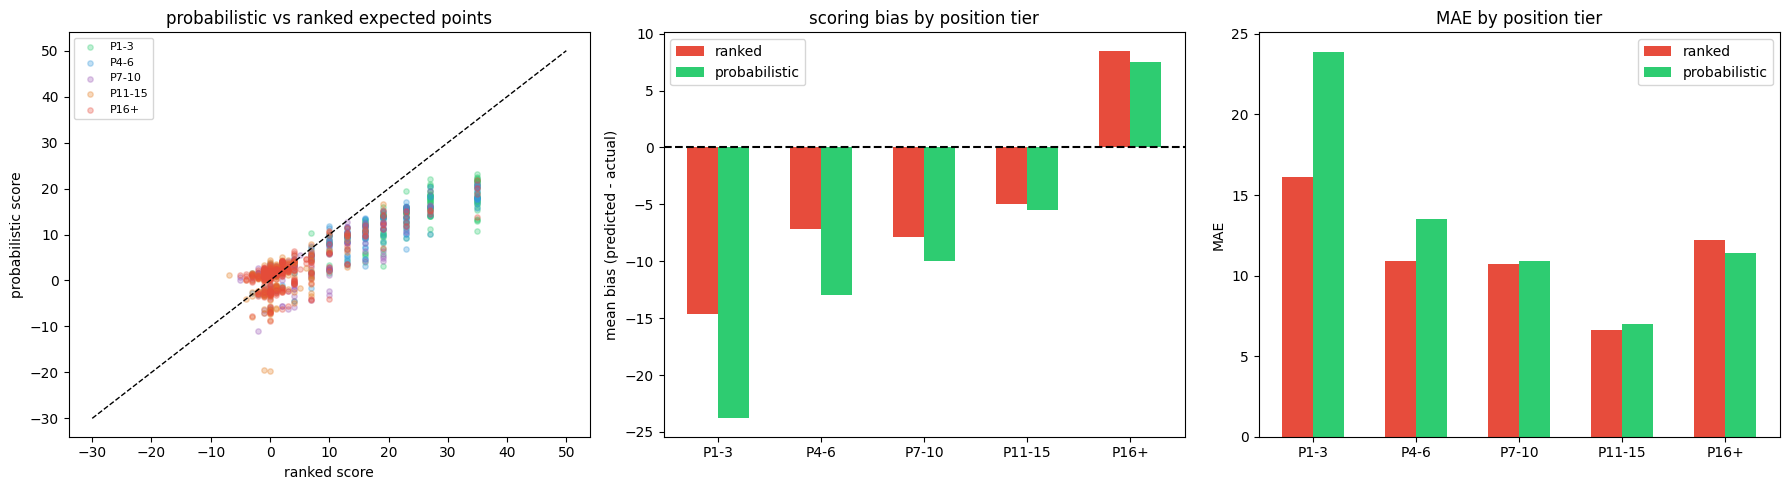

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# scatter: prob vs ranked, colored by tier
colors = {"P1-3": "#2ecc71", "P4-6": "#3498db", "P7-10": "#9b59b6", "P11-15": "#e67e22", "P16+": "#e74c3c"}
for tier, color in colors.items():
    sub = eval_data[eval_data["finish_tier"] == tier]
    axes[0].scatter(sub["ranked_score"], sub["prob_score"], alpha=0.3, s=15, color=color, label=tier)
lims = [-30, 50]
axes[0].plot(lims, lims, "k--", lw=1)
axes[0].set_xlabel("ranked score")
axes[0].set_ylabel("probabilistic score")
axes[0].set_title("probabilistic vs ranked expected points")
axes[0].legend(fontsize=8)

# bias comparison by tier
tiers = tier_compare.index.tolist()
x = np.arange(len(tiers))
axes[1].bar(x - 0.15, tier_compare["ranked_bias"], width=0.3, color="#e74c3c", label="ranked")
axes[1].bar(x + 0.15, tier_compare["prob_bias"], width=0.3, color="#2ecc71", label="probabilistic")
axes[1].set_xticks(x)
axes[1].set_xticklabels(tiers)
axes[1].axhline(0, color="black", ls="--")
axes[1].set_ylabel("mean bias (predicted - actual)")
axes[1].set_title("scoring bias by position tier")
axes[1].legend()

# MAE comparison by tier
axes[2].bar(x - 0.15, tier_compare["ranked_mae"], width=0.3, color="#e74c3c", label="ranked")
axes[2].bar(x + 0.15, tier_compare["prob_mae"], width=0.3, color="#2ecc71", label="probabilistic")
axes[2].set_xticks(x)
axes[2].set_xticklabels(tiers)
axes[2].set_ylabel("MAE")
axes[2].set_title("MAE by position tier")
axes[2].legend()

plt.tight_layout()
plt.show()

## Sigma sweep

The sigma function was fit on training data. Try scaling it up/down to see if a different
spread improves accuracy. Also try a flat sigma for simplicity.

In [9]:
def score_with_sigma(eval_df, sigma_func):
    """score all drivers using a given sigma function, return MAE and bias."""
    errors = []
    for _, row in eval_df.iterrows():
        sf = sigma_func(row["raw_finish"])
        sq = sigma_func(row["raw_quali"])
        dnf = row["dnf_rate"] if not pd.isna(row["dnf_rate"]) else 0.0
        result = expected_race_points(row["raw_finish"], sf, row["raw_quali"], sq, dnf_rate=dnf)
        errors.append(result["expected_points"] - row["actual_fantasy_pts"])
    errors = np.array(errors)
    return errors.mean(), np.abs(errors).mean()

# scale the fitted sigma
print("=== sigma scaling ===")
for scale in [0.5, 0.75, 1.0, 1.25, 1.5, 2.0]:
    scaled_fn = lambda raw, s=scale: max(s * (coeffs[0] + coeffs[1] * raw), 1.0)
    bias, mae = score_with_sigma(eval_data, scaled_fn)
    print(f"  scale={scale:.2f}: MAE={mae:.2f}  bias={bias:+.2f}")

# flat sigma
print("\n=== flat sigma ===")
for flat in [2.0, 3.0, 4.0, 5.0, 6.0, 7.0]:
    flat_fn = lambda raw, f=flat: f
    bias, mae = score_with_sigma(eval_data, flat_fn)
    print(f"  sigma={flat:.1f}: MAE={mae:.2f}  bias={bias:+.2f}")

# for reference
print(f"\nranked baseline: MAE={eval_data['ranked_error'].abs().mean():.2f}  bias={eval_data['ranked_error'].mean():+.2f}")

=== sigma scaling ===
  scale=0.50: MAE=12.83  bias=-7.82
  scale=0.75: MAE=12.63  bias=-7.42
  scale=1.00: MAE=12.40  bias=-6.92
  scale=1.25: MAE=12.22  bias=-6.43
  scale=1.50: MAE=12.14  bias=-6.05
  scale=2.00: MAE=12.18  bias=-5.59

=== flat sigma ===
  sigma=2.0: MAE=12.76  bias=-7.68
  sigma=3.0: MAE=12.62  bias=-7.35
  sigma=4.0: MAE=12.56  bias=-7.06
  sigma=5.0: MAE=12.55  bias=-6.78
  sigma=6.0: MAE=12.57  bias=-6.54
  sigma=7.0: MAE=12.62  bias=-6.34

ranked baseline: MAE=10.91  bias=-3.89


## Dashboard preview: what this looks like per driver

Show a sample race with predicted position, confidence interval, and expected points
for both methods.

In [10]:
# pick a recent race as example
sample = eval_data[(eval_data["season"] == 2026) & (eval_data["round"] == 5)].sort_values("raw_finish")

print(f"2026 Round 5 - driver predictions\n")
print(f"{'Driver':<25} {'Pred':>5} {'P(80% CI)':>12} {'Prob Pts':>9} {'Ranked Pts':>11} {'Actual':>7}")
print("-" * 75)

for _, row in sample.iterrows():
    sf = sigma_fn(row["raw_finish"])
    sq = sigma_fn(row["raw_quali"])
    dnf = row["dnf_rate"] if not pd.isna(row["dnf_rate"]) else 0.0
    result = expected_race_points(row["raw_finish"], sf, row["raw_quali"], sq, dnf_rate=dnf)

    ci = f"P{result['upper_finish']}-P{result['lower_finish']}"
    print(f"{row['driver_id']:<25} {row['raw_finish']:>5.1f} {ci:>12} {result['expected_points']:>9.1f} {row['ranked_score']:>11.0f} {row['actual_fantasy_pts']:>7.0f}")

2026 Round 5 - driver predictions

Driver                     Pred    P(80% CI)  Prob Pts  Ranked Pts  Actual
---------------------------------------------------------------------------
george_russell              3.7        P1-P6      20.1          35       4
andrea_kimi_antonelli       4.3        P2-P7      18.4          27      62
charles_leclerc             6.0        P3-P9      13.1          23      27
lewis_hamilton              7.2       P4-P11      10.1          19      42
lando_norris                7.2       P4-P11      10.0          16       6
oscar_piastri               8.2       P4-P12       2.9          13      12
max_verstappen             10.3       P6-P14       3.4          10      26
isack_hadjar               11.8       P7-P16      -1.6           7       6
nico_hulkenberg            12.2       P8-P17       3.5           4       1
franco_colapinto           12.2       P8-P17       3.6           2      25
carlos_sainz               12.6       P8-P17       3.1          

## Next steps

If probabilistic scoring improves MAE and reduces tier bias:
1. Update `compose_drivers` to accept raw predictions and use probabilistic scoring
2. Pass upper/lower bounds through to the dashboard for display
3. Re-run backtest to measure team-level points improvement
4. Consider whether the optimiser should use expected value (risk-neutral) or incorporate
   variance (risk-aware team selection)